# 08 · Ajuste de hiperparámetros de YOLO26s

Comprueba si pequeños cambios de hiperparámetros mejoran el modelo YOLO26s a
768 px. Como cada entrenamiento completo es muy costoso, se entrenan cuatro
variantes durante 50 épocas y se comparan con las primeras 50 épocas del
entrenamiento de referencia.

## Guía de lectura y ejecución

| Aspecto | Descripción |
|---|---|
| **Papel en el proyecto** | Prueba cuatro cambios de hiperparámetros sobre YOLO26s a 768 px con entrenamientos cortos de 50 épocas. |
| **Cuándo abrirlo** | Para ver el ajuste de hiperparámetros (Tabla 6 de la memoria). |
| **Comportamiento por defecto** | No entrena ni evalúa (`RUN_TRAINING`, `RUN_EVALUATION` y `RUN_FINAL_TRAINING` a `False`). |
| **Entradas principales** | Dataset preparado, entrenamiento de referencia de YOLO26s y `configs/yolo26s_hyperparameter_search.yaml`. |
| **Salidas principales** | Un experimento por ensayo en `artifacts/experiments/`. |
| **Continuación** | `09_DFire_seleccion_final_validacion.ipynb`. |

> **Para ejecutarlo:** usar el entorno Docker de notebooks (sección 4 del
> `README.md` principal). Volver a ejecutarlo requiere resultados intermedios
> (`artifacts/experiments/` y otras carpetas de `artifacts/`) que no están en el
> repositorio; ver `notebooks/README.md`.

## 1. Diseño

Cada ensayo cambia un solo bloque de hiperparámetros:

- **HP01:** tasa de aprendizaje inicial 5×10⁻⁴ (en lugar de 1×10⁻³).
- **HP02:** weight decay 1×10⁻³.
- **HP03:** aumento de datos más suave: menos variación de color, traslación y
  escala, y mosaico en el 70 % de las imágenes en lugar del 100 %.
- **HP04:** combinación de HP01 y HP03.

El resto no cambia: mismo dataset, resolución, optimizador, batch y semilla. El
entrenamiento de referencia no se repite; se usan sus primeras 50 épocas para
que la comparación sea justa. Solo se usa validación.

## 2. Parámetros

- `RUN_TRAINING=True`: lanza los cuatro entrenamientos de 50 épocas (unas 9,4
  horas; si se interrumpen, se pueden reanudar).
- `RUN_EVALUATION=True`: evalúa los ensayos sobre validación (también con
  `tools/run_hyperparameter_evaluation.py`).
- `RUN_FINAL_TRAINING=True` con `FINAL_TRIAL_ID`: entrena desde cero, durante
  100 épocas, el ensayo elegido.

In [1]:
RUN_TRAINING = False
RUN_EVALUATION = False
EVALUATION_OFFLINE = False
RUN_FINAL_TRAINING = False
RESUME_INCOMPLETE = True
CONTINUE_ON_ERROR = True
CONFIG_PATH = "configs/yolo26s_hyperparameter_search.yaml"

# None usa exactamente active_trials del YAML. Para una prueba controlada puede
# indicarse, por ejemplo, ["hp01_lr5e4"].
TRIAL_IDS = None

# Segunda fase. Debe fijarse manualmente tras revisar el cribado y la evaluación
# operativa. Ejemplo: "hp04_lr5e4_conservative_aug".
FINAL_TRIAL_ID = None
FINAL_SEED = 42

ALLOW_CPU_TRAINING = False
WORKERS = 4
USE_FAST_LOCAL_DATASET = True
FAST_DATA_ROOT = None
STAGING_WORKERS = 8


## 3. Cargar la configuración y comprobar el plan

In [2]:
from pathlib import Path
import datetime as dt
import gc
import os
import random
import sys

import numpy as np
import pandas as pd
import torch
import yaml
from IPython.display import display, Markdown
from ultralytics import YOLO

roots = [Path(os.environ["TFM_PROJECT_ROOT"])] if os.environ.get("TFM_PROJECT_ROOT") else []
roots += [Path.cwd(), *Path.cwd().parents]
PROJECT_ROOT = next((p for p in roots if (p / "tfm_pipeline.py").is_file()), None)
if PROJECT_ROOT is None:
    raise FileNotFoundError("Abrir el notebook dentro de la carpeta del proyecto o definir TFM_PROJECT_ROOT.")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
import tfm_pipeline as pipeline

PROJECT_ROOT = pipeline.project_root()
config_path = PROJECT_ROOT / CONFIG_PATH
config = yaml.safe_load(config_path.read_text(encoding="utf-8"))
if config.get("schema_version") != 2:
    raise ValueError("Solo se admite schema_version=2.")
if config.get("model_key") != "yolo26s":
    raise ValueError("Este cuaderno está limitado explícitamente a YOLO26s.")
if not config.get("selection", {}).get("test_locked"):
    raise ValueError("La configuración debe mantener test_locked=true.")

trial_ids = list(config["active_trials"] if TRIAL_IDS is None else TRIAL_IDS)
unknown = set(trial_ids) - set(config["trials"])
if unknown:
    raise KeyError(f"Ensayos desconocidos: {sorted(unknown)}")
if len(trial_ids) != len(set(trial_ids)):
    raise ValueError("TRIAL_IDS contiene duplicados.")

estimated_hours = len(trial_ids) * float(config["expected_hours_per_screening_run"])
if estimated_hours > float(config["night_budget_hours"]):
    raise ValueError(
        f"La cola estimada ({estimated_hours:.1f} h) supera el presupuesto nocturno "
        f"({config['night_budget_hours']:.1f} h)."
    )

screening_parameters = dict(config["screening_parameters"])
if screening_parameters.get("epochs") != config["screening_epochs"]:
    raise ValueError("screening_parameters.epochs debe coincidir con screening_epochs.")
if config["selection"].get("screening_horizon_epochs") != config["screening_epochs"]:
    raise ValueError("El horizonte de selección debe coincidir con el cribado.")

if RUN_FINAL_TRAINING and FINAL_TRIAL_ID not in config["trials"]:
    raise ValueError("Para la fase final debes fijar FINAL_TRIAL_ID a un ensayo conocido.")

rows = []
for trial_id in trial_ids:
    spec = config["trials"][trial_id]
    effective = screening_parameters | dict(spec.get("overrides", {}))
    rows.append({
        "ensayo": trial_id,
        "experiment_id": spec["experiment_id"],
        "seed": spec["seed"],
        "epochs": effective["epochs"],
        "lr0": effective.get("lr0"),
        "weight_decay": effective.get("weight_decay", "Ultralytics"),
        "hsv_s": effective.get("hsv_s", "Ultralytics"),
        "scale": effective.get("scale", "Ultralytics"),
        "mosaic": effective.get("mosaic", "Ultralytics"),
        "estimación_h": config["expected_hours_per_screening_run"],
        "justificación": spec["rationale"],
    })

display(pd.DataFrame(rows))
display(pd.Series({
    "search_id": config["search_id"],
    "baseline": config["baseline_experiment_id"],
    "ensayos_nuevos": len(trial_ids),
    "configuraciones_de_cribado_con_baseline": 1 + len(trial_ids),
    "duración_estimativa_h": estimated_hours,
    "presupuesto_nocturno_h": config["night_budget_hours"],
}, name="valor").to_frame())


,ensayo,experiment_id,seed,epochs,lr0,weight_decay,hsv_s,scale,mosaic,estimación_h,justificación
0,hp01_lr5e4,yolo26s_hp01_lr5e4_50ep_seed42,42,50,0.0005,Ultralytics,Ultralytics,Ultralytics,Ultralytics,2.35,Reducir lr0 manteniendo los aumentos y la regu...
1,hp02_weight_decay1e3,yolo26s_hp02_weight_decay1e3_50ep_seed42,42,50,0.0010,0.001,Ultralytics,Ultralytics,Ultralytics,2.35,Duplicar weight decay para comprobar si reduce...
2,hp03_conservative_aug,yolo26s_hp03_conservative_aug_50ep_seed42,42,50,0.0010,Ultralytics,0.45,0.25,0.7,2.35,Reducir transformaciones de color y geometría ...
3,hp04_lr5e4_conservative_aug,yolo26s_hp04_lr5e4_conservative_aug_50ep_seed42,42,50,0.0005,Ultralytics,0.45,0.25,0.7,2.35,Comprobar la interacción entre lr0 conservador...


,valor
search_id,yolo26s_multifidelity_hp_v2
baseline,yolo26s_dfire_seed42_20260912T165304Z
ensayos_nuevos,4
configuraciones_de_cribado_con_baseline,5
duración_estimativa_h,9.4
presupuesto_nocturno_h,10.0


## 4. Comprobaciones previas

In [3]:
contract = pipeline.validate_prepared_dataset(PROJECT_ROOT, config["dataset_version"])
registry = pipeline.load_model_registry(PROJECT_ROOT)
model_config = dict(registry["models"][config["model_key"]])
initial_weights = pipeline.resolve_model_weights(model_config, PROJECT_ROOT)
baseline = pipeline.resolve_experiment(
    experiment_id=config["baseline_experiment_id"], root=PROJECT_ROOT
)
if baseline["status"] != "complete" or baseline["model_key"] != "yolo26s":
    raise ValueError("El baseline declarado no es un YOLO26s completo.")
if baseline["dataset_version"] != config["dataset_version"]:
    raise ValueError("El baseline utiliza otra versión del dataset.")
if baseline.get("dataset_manifest_sha256") != pipeline.sha256_file(contract["manifest_path"]):
    raise ValueError("El manifiesto del baseline no coincide con el dataset preparado.")

DEVICE = 0 if torch.cuda.is_available() else "cpu"
if (RUN_TRAINING or RUN_FINAL_TRAINING) and DEVICE == "cpu" and not ALLOW_CPU_TRAINING:
    raise RuntimeError("Entrenamiento bloqueado: CUDA no está disponible.")

environment = pipeline.environment_snapshot()
display(pd.Series({
    "pesos_iniciales": initial_weights,
    "dataset": config["dataset_version"],
    "manifest_sha256": pipeline.sha256_file(contract["manifest_path"]),
    "dispositivo": environment["gpu_name"] or "CPU",
    "test_cargado": False,
}, name="valor").to_frame())
print("Preflight correcto. El conjunto de test no se ha cargado.")


,valor
pesos_iniciales,yolo26s.pt
dataset,dfire_seed42_val10_v1
manifest_sha256,97442af38322abe1bf5178bd6b92c30971d9f354eca319...
dispositivo,NVIDIA GeForce RTX 5070
test_cargado,False


Preflight correcto. El conjunto de test no se ha cargado.


## 5. Entrenar o reanudar los cuatro ensayos

In [4]:
completed_runs = []
failed_runs = []
skipped_runs = []

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def update_descriptor(descriptor_path, **updates):
    descriptor = pipeline.read_json(descriptor_path)
    descriptor.update(updates)
    pipeline.write_json_atomic(descriptor_path, descriptor)
    return pipeline.resolve_descriptor_paths(descriptor, PROJECT_ROOT)

if RUN_TRAINING:
    staging_base = (
        Path(FAST_DATA_ROOT) if FAST_DATA_ROOT
        else pipeline.default_fast_data_root(PROJECT_ROOT)
        if USE_FAST_LOCAL_DATASET
        else PROJECT_ROOT / "artifacts" / "runtime_datasets"
    )
    staged_dataset = pipeline.stage_prepared_dataset(
        contract, fast_base=staging_base, workers=STAGING_WORKERS
    )

    for position, trial_id in enumerate(trial_ids, start=1):
        spec = config["trials"][trial_id]
        experiment_id = spec["experiment_id"]
        experiment_root = pipeline.experiments_root(PROJECT_ROOT) / experiment_id
        descriptor_path = experiment_root / "experiment.json"
        training_model = None
        try:
            if descriptor_path.exists():
                existing = pipeline.resolve_descriptor_paths(
                    pipeline.read_json(descriptor_path), PROJECT_ROOT
                )
                if existing["status"] == "complete":
                    print(f"[{position}/{len(trial_ids)}] Ya completo: {experiment_id}")
                    completed_runs.append(existing)
                    skipped_runs.append(experiment_id)
                    continue
                checkpoint = Path(existing["last_model"])
                if not RESUME_INCOMPLETE or not checkpoint.exists():
                    raise FileExistsError(
                        f"Existe un experimento incompleto sin reanudación utilizable: {experiment_id}"
                    )
                print(f"[{position}/{len(trial_ids)}] Reanudando {experiment_id}")
                training_model = YOLO(str(checkpoint))
                training_result = training_model.train(resume=True)
            else:
                experiment_root.mkdir(parents=True)
                runtime_yaml = pipeline.write_runtime_data_yaml(
                    contract, experiment_root / "data_runtime.yaml", staged_dataset
                )
                train_config = screening_parameters | dict(spec.get("overrides", {}))
                expected_run_dir = experiment_root / "train"
                descriptor = {
                    "schema_version": 1,
                    "experiment_id": experiment_id,
                    "search_id": config["search_id"],
                    "trial_id": trial_id,
                    "queue_position": position,
                    "created_utc": dt.datetime.now(dt.timezone.utc).isoformat(),
                    "status": "running",
                    "model_key": config["model_key"],
                    "model_family": model_config["family"],
                    "model_scale": model_config["scale"],
                    "initial_weights": initial_weights,
                    "dataset_version": config["dataset_version"],
                    "dataset_manifest_sha256": pipeline.sha256_file(contract["manifest_path"]),
                    "profile": f"{config['search_id']}_screening_50ep",
                    "fidelity": "screening",
                    "seed": int(spec["seed"]),
                    "train_config": train_config,
                    "hyperparameter_rationale": spec["rationale"],
                    "training_run_dir_rel": pipeline.project_relative(expected_run_dir, PROJECT_ROOT),
                    "best_model_rel": pipeline.project_relative(expected_run_dir / "weights" / "best.pt", PROJECT_ROOT),
                    "last_model_rel": pipeline.project_relative(expected_run_dir / "weights" / "last.pt", PROJECT_ROOT),
                }
                pipeline.write_json_atomic(descriptor_path, descriptor)
                pipeline.write_json_atomic(experiment_root / "environment.json", environment)
                print(f"[{position}/{len(trial_ids)}] Iniciando {experiment_id}")
                set_seed(int(spec["seed"]))
                training_model = YOLO(initial_weights)
                training_result = training_model.train(
                    data=str(runtime_yaml),
                    device=DEVICE,
                    workers=WORKERS,
                    project=str(experiment_root),
                    name="train",
                    exist_ok=False,
                    seed=int(spec["seed"]),
                    **train_config,
                )

            run_dir = Path(training_result.save_dir)
            completed = update_descriptor(
                descriptor_path,
                status="complete",
                completed_utc=dt.datetime.now(dt.timezone.utc).isoformat(),
                training_run_dir_rel=pipeline.project_relative(run_dir, PROJECT_ROOT),
                best_model_rel=pipeline.project_relative(run_dir / "weights" / "best.pt", PROJECT_ROOT),
                last_model_rel=pipeline.project_relative(run_dir / "weights" / "last.pt", PROJECT_ROOT),
            )
            completed_runs.append(completed)
            print(f"Completado: {experiment_id}")
        except BaseException as exc:
            if descriptor_path.exists():
                update_descriptor(
                    descriptor_path,
                    status="failed",
                    failed_utc=dt.datetime.now(dt.timezone.utc).isoformat(),
                    error_type=type(exc).__name__,
                    error_message=str(exc),
                )
            failed_runs.append({
                "experiment_id": experiment_id,
                "error_type": type(exc).__name__,
                "error_message": str(exc),
            })
            print(f"Falló {experiment_id}: {type(exc).__name__}: {exc}")
            if not CONTINUE_ON_ERROR or isinstance(exc, (KeyboardInterrupt, SystemExit)):
                raise
        finally:
            del training_model
            gc.collect()
            if torch.cuda.is_available():
                torch.cuda.empty_cache()
else:
    print("Modo seguro: RUN_TRAINING=False; no se ha iniciado el cribado.")


Modo seguro: RUN_TRAINING=False; no se ha iniciado el cribado.


## 6. Resultados de los entrenamientos

,experiment_id,trial_id,estado,horizonte_comparado,mejor_época,mAP50-95,mAP50,precisión,recall,épocas_totales_disponibles
1,yolo26s_hp01_lr5e4_50ep_seed42,hp01_lr5e4,complete,50,38,0.4612,0.7919,0.7856,0.7233,50
0,yolo26s_dfire_seed42_20260912T165304Z,baseline,complete,50,50,0.4578,0.7933,0.7821,0.7282,89
4,yolo26s_hp04_lr5e4_conservative_aug_50ep_seed42,hp04_lr5e4_conservative_aug,complete,50,35,0.4538,0.7816,0.7811,0.7175,50
2,yolo26s_hp02_weight_decay1e3_50ep_seed42,hp02_weight_decay1e3,complete,50,45,0.4532,0.7874,0.7686,0.7357,50
3,yolo26s_hp03_conservative_aug_50ep_seed42,hp03_conservative_aug,complete,50,37,0.4523,0.7786,0.7877,0.6960,50


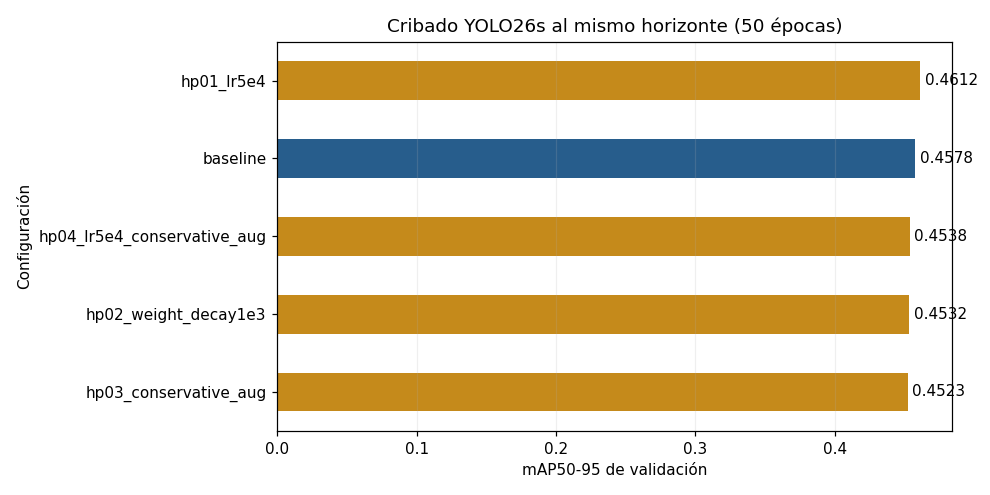

In [5]:
def training_summary(experiment, horizon_epochs):
    results_path = Path(experiment["training_run_dir"]) / "results.csv"
    if not results_path.exists():
        return None
    results = pd.read_csv(results_path)
    results.columns = [column.strip() for column in results.columns]
    results = results.iloc[:horizon_epochs].copy()
    metric = config["selection"]["primary_metric"]
    if metric not in results:
        raise KeyError(f"Falta la métrica {metric!r} en {results_path}.")
    best_index = results[metric].astype(float).idxmax()
    best = results.loc[best_index]
    trial_id = experiment.get("trial_id")
    return {
        "experiment_id": experiment["experiment_id"],
        "trial_id": trial_id if isinstance(trial_id, str) else "baseline",
        "estado": experiment["status"],
        "horizonte_comparado": len(results),
        "mejor_época": int(best["epoch"]),
        "mAP50-95": float(best["metrics/mAP50-95(B)"]),
        "mAP50": float(best["metrics/mAP50(B)"]),
        "precisión": float(best["metrics/precision(B)"]),
        "recall": float(best["metrics/recall(B)"]),
        "épocas_totales_disponibles": len(pd.read_csv(results_path)),
    }

available_experiments = [baseline]
for trial_id in trial_ids:
    descriptor = pipeline.experiments_root(PROJECT_ROOT) / config["trials"][trial_id]["experiment_id"] / "experiment.json"
    if descriptor.exists():
        candidate = pipeline.resolve_descriptor_paths(pipeline.read_json(descriptor), PROJECT_ROOT)
        if candidate.get("status") == "complete":
            available_experiments.append(candidate)

screening_horizon = int(config["selection"]["screening_horizon_epochs"])
summary_rows = [training_summary(exp, screening_horizon) for exp in available_experiments]
summary_rows = [row for row in summary_rows if row is not None]
summary_table = pd.DataFrame(summary_rows).sort_values("mAP50-95", ascending=False)
display(summary_table.style.format({
    "mAP50-95": "{:.4f}", "mAP50": "{:.4f}",
    "precisión": "{:.4f}", "recall": "{:.4f}",
}))

if failed_runs:
    display(Markdown("### Ejecuciones fallidas"))
    display(pd.DataFrame(failed_runs))
if skipped_runs:
    print("Ya estaban completas y no se repitieron:", ", ".join(skipped_runs))

if len(summary_table) > 1:
    import matplotlib.pyplot as plt
    plot_table = summary_table.sort_values("mAP50-95")
    colors = ["#275D8C" if value == "baseline" else "#C58A1B" for value in plot_table["trial_id"]]
    ax = plot_table.plot.barh(
        x="trial_id", y="mAP50-95", color=colors, legend=False, figsize=(9, 4.5)
    )
    ax.set(
        title=f"Cribado YOLO26s al mismo horizonte ({screening_horizon} épocas)",
        xlabel="mAP50-95 de validación", ylabel="Configuración",
    )
    ax.grid(axis="x", alpha=.2)
    for container in ax.containers:
        ax.bar_label(container, fmt="%.4f", padding=3)
    plt.tight_layout()
    # Se muestra como PNG para que funcione también con MPLBACKEND=Agg (Docker).
    import io
    from IPython.display import Image as DisplayImage
    buffer = io.BytesIO()
    ax.figure.savefig(buffer, format="png", dpi=110)
    plt.close(ax.figure)
    display(DisplayImage(buffer.getvalue()))


## 7. Evaluación de los ensayos

In [6]:
if RUN_EVALUATION:
    import subprocess
    command = [sys.executable, str(PROJECT_ROOT / "tools" / "run_hyperparameter_evaluation.py")]
    if EVALUATION_OFFLINE:
        command.append("--offline")
    subprocess.run(command, cwd=PROJECT_ROOT, check=True)
else:
    print("Evaluación desactivada. Puede revisarse el estado con:")
    print("python tools/run_hyperparameter_evaluation.py --preflight")


Evaluación desactivada. Puede revisarse el estado con:
python tools/run_hyperparameter_evaluation.py --preflight


## 8. Entrenamiento completo del ensayo elegido

In [7]:
final_run = None
if RUN_FINAL_TRAINING:
    spec = config["trials"][FINAL_TRIAL_ID]
    final_experiment_id = f"yolo26s_hp_final_{FINAL_TRIAL_ID}_100ep_seed{FINAL_SEED}"
    final_root = pipeline.experiments_root(PROJECT_ROOT) / final_experiment_id
    final_descriptor_path = final_root / "experiment.json"

    if final_descriptor_path.exists():
        existing = pipeline.resolve_descriptor_paths(
            pipeline.read_json(final_descriptor_path), PROJECT_ROOT
        )
        if existing["status"] == "complete":
            final_run = existing
            print(f"El entrenamiento final ya estaba completo: {final_experiment_id}")
        else:
            checkpoint = Path(existing["last_model"])
            if not RESUME_INCOMPLETE or not checkpoint.exists():
                raise FileExistsError("Existe una fase final incompleta sin checkpoint reanudable.")
            print(f"Reanudando entrenamiento final: {final_experiment_id}")
            final_model = YOLO(str(checkpoint))
            final_result = final_model.train(resume=True)
    else:
        staging_base = (
            Path(FAST_DATA_ROOT) if FAST_DATA_ROOT
            else pipeline.default_fast_data_root(PROJECT_ROOT)
            if USE_FAST_LOCAL_DATASET
            else PROJECT_ROOT / "artifacts" / "runtime_datasets"
        )
        staged_dataset = pipeline.stage_prepared_dataset(
            contract, fast_base=staging_base, workers=STAGING_WORKERS
        )
        final_root.mkdir(parents=True)
        runtime_yaml = pipeline.write_runtime_data_yaml(
            contract, final_root / "data_runtime.yaml", staged_dataset
        )
        final_config = dict(config["final_parameters"]) | dict(spec.get("overrides", {}))
        expected_run_dir = final_root / "train"
        final_descriptor = {
            "schema_version": 1,
            "experiment_id": final_experiment_id,
            "search_id": config["search_id"],
            "source_trial_id": FINAL_TRIAL_ID,
            "created_utc": dt.datetime.now(dt.timezone.utc).isoformat(),
            "status": "running",
            "model_key": config["model_key"],
            "model_family": model_config["family"],
            "model_scale": model_config["scale"],
            "initial_weights": initial_weights,
            "dataset_version": config["dataset_version"],
            "dataset_manifest_sha256": pipeline.sha256_file(contract["manifest_path"]),
            "profile": f"{config['search_id']}_final_100ep",
            "fidelity": "full",
            "seed": int(FINAL_SEED),
            "train_config": final_config,
            "hyperparameter_rationale": spec["rationale"],
            "training_run_dir_rel": pipeline.project_relative(expected_run_dir, PROJECT_ROOT),
            "best_model_rel": pipeline.project_relative(expected_run_dir / "weights" / "best.pt", PROJECT_ROOT),
            "last_model_rel": pipeline.project_relative(expected_run_dir / "weights" / "last.pt", PROJECT_ROOT),
        }
        pipeline.write_json_atomic(final_descriptor_path, final_descriptor)
        pipeline.write_json_atomic(final_root / "environment.json", environment)
        print(f"Iniciando entrenamiento final desde pesos iniciales: {final_experiment_id}")
        set_seed(int(FINAL_SEED))
        final_model = YOLO(initial_weights)
        final_result = final_model.train(
            data=str(runtime_yaml), device=DEVICE, workers=WORKERS,
            project=str(final_root), name="train", exist_ok=False,
            seed=int(FINAL_SEED), **final_config,
        )

    if final_run is None:
        final_run_dir = Path(final_result.save_dir)
        final_run = update_descriptor(
            final_descriptor_path,
            status="complete",
            completed_utc=dt.datetime.now(dt.timezone.utc).isoformat(),
            training_run_dir_rel=pipeline.project_relative(final_run_dir, PROJECT_ROOT),
            best_model_rel=pipeline.project_relative(final_run_dir / "weights" / "best.pt", PROJECT_ROOT),
            last_model_rel=pipeline.project_relative(final_run_dir / "weights" / "last.pt", PROJECT_ROOT),
        )
        del final_model
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
    display(pd.Series({
        "experimento_final": final_run["experiment_id"],
        "receta_origen": FINAL_TRIAL_ID,
        "épocas_máximas": final_run["train_config"]["epochs"],
        "best.pt": final_run["best_model"],
    }, name="valor").to_frame())
else:
    print("Fase final desactivada. Evalúa primero los cribados y fija FINAL_TRIAL_ID.")


Fase final desactivada. Evalúa primero los cribados y fija FINAL_TRIAL_ID.


## 9. Resultado

Solo HP01 mejoró ligeramente a la referencia a 50 épocas (+0,34 puntos de
mAP50-95); los otros tres empeoraron. HP01 también fue el mejor de los cuatro
con el criterio del 1 % de falsas alarmas (notebook 10).

La mejora es pequeña y se obtuvo con una sola semilla y la mitad de épocas, así
que no se puede atribuir con seguridad al cambio de hiperparámetro. Por eso se
mantuvo el entrenamiento de referencia para la selección final y no se usó la
fase de entrenamiento completo (sección 8).

Es un ajuste manual limitado por el coste de cálculo, no una búsqueda
exhaustiva de hiperparámetros.